# 0. INTRODUCCION AL DATASET

El punto de partida de este trabajo es `listings.csv`, un dataset de kaggle con anuncios de Airbnb. Este notebook es nuestro primer acercamiento al conjunto de datos y ver las principales caracteristicas de este e ir afinando como vamos a enfocar el trabajo.

## Índice

 **1. ¿Qué hay en el fichero y con qué detalle?**  
 **2. ¿Son comparables los precios entre ciudades?**  
 **3. ¿Se comporta el precio igual en todas?** 


No se da nada por sabido: todo lo que se afirma sale de una celda de este notebook. El precio aparece siempre
agregado y dentro de cada ciudad (medianas y cocientes), lo justo para compararlas entre sí.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path.cwd().parent / 'data'
SURFACE, INK, INK_MUTED = '#fcfcfb', '#0b0b0b', '#898781'
COLOR_FOCO, COLOR_CONTEXTO = '#2a6f97', '#9aa5b1'
COLUMNAS = ['listing_id', 'host_id', 'city', 'district', 'neighbourhood', 'latitude', 'longitude',
            'room_type', 'accommodates', 'price']

columnas_origen = pd.read_csv(DATA_DIR / 'listings.csv', nrows=0).columns.tolist()
print(f'{len(columnas_origen)} variablses en el CSV original.')

listings = pd.read_csv(DATA_DIR / 'listings.csv', usecols=COLUMNAS, low_memory=False)
# Sin capacidad no hay producto que valorar y sin precio no hay nada que predecir
validos = listings[(listings['price'] > 0) & (listings['accommodates'] > 0)]
print(f"\n{len(listings):,} anuncios | {listings['city'].nunique()} ciudades | "
      f"{listings['city'].isna().sum()} sin ciudad")
print(f"{len(validos):,} con precio y capacidad utilizables ({len(validos) / len(listings):.1%})")

33 columnas en el fichero:
listing_id, name, host_id, host_since, host_location, host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost, host_total_listings_count, host_has_profile_pic, host_identity_verified, neighbourhood, district, city, latitude, longitude, property_type, room_type, accommodates, bedrooms, amenities, price, minimum_nights, maximum_nights, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, instant_bookable

279,712 anuncios | 10 ciudades | 0 sin ciudad
279,599 con precio y capacidad utilizables (100.0%)


Diez ciudades de cuatro continentes en un solo fichero. Y una ausencia que marca toda la sección 2: **entre
las columnas no hay ninguna de divisa**. Volveremos a ello.

In [ ]:
def ranking(serie, titulo, formato='{:,.0f}', destacar=None):
    """Barras horizontales ordenadas; `destacar` colorea una ciudad y el valor va escrito en cada barra.

    La cifra va escrita, y no solo codificada en la longitud, porque el gris de contexto no llega a 3:1 de
    contraste con el fondo: quien no distinga los colores sigue leyendo el grafico.
    """
    serie = serie.sort_values()
    colores = [COLOR_FOCO if ciudad == destacar else COLOR_CONTEXTO for ciudad in serie.index]
    fig, eje = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    eje.barh(serie.index, serie.values, color=colores, height=0.68)
    for ciudad, valor in serie.items():
        eje.text(valor, ciudad, '  ' + formato.format(valor), va='center', fontsize=9, color=INK_MUTED)
    eje.set_xlim(0, serie.max() * 1.2)
    eje.set_title(titulo, loc='left', fontsize=12, color=INK, fontweight='bold')
    eje.spines[['top', 'right', 'left']].set_visible(False)
    eje.tick_params(colors=INK_MUTED, length=0)
    eje.xaxis.set_visible(False)
    plt.tight_layout()
    plt.show()

## 1. ¿QUÉ HAY EN EL FICHERO Y CON QUÉ DETALLE?

Un modelo de precio de alojamiento vive o muere por la ubicación: dos pisos idénticos a tres kilómetros de
distancia valen cosas distintas. Así que lo primero no es cuántos anuncios hay, sino **con qué resolución se
puede situar cada uno**.

El fichero trae tres niveles geográficos: las coordenadas, `neighbourhood` (el barrio) y `district`, una
división administrativa intermedia. Veamos qué tiene cada ciudad.

,anuncios,anfitriones,barrios,coords_nulas,pct_district,anuncios_por_barrio
city,,,,,,
Paris,64690,51955,20,0,0.0,3234.0
New York,37012,26765,220,0,100.0,168.0
Sydney,33630,24965,38,0,0.0,885.0
Rome,27647,14592,15,0,0.0,1843.0
Rio de Janeiro,26615,17324,151,0,0.0,176.0
Istanbul,24519,13566,39,0,0.0,629.0
Mexico City,20065,11527,16,0,0.0,1254.0
Bangkok,19361,8327,50,0,0.0,387.0
Cape Town,19086,11118,93,0,0.0,205.0


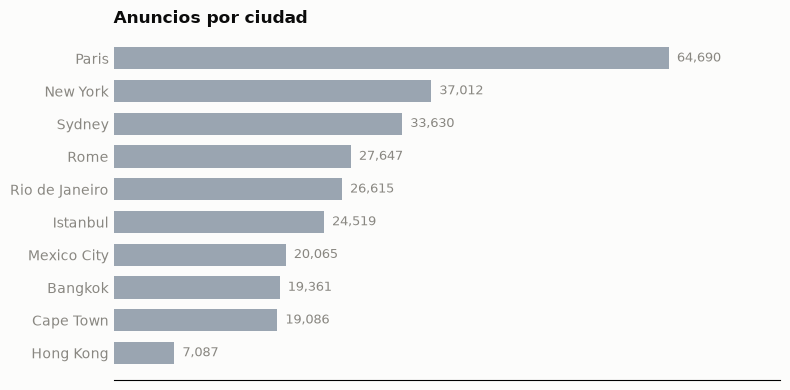

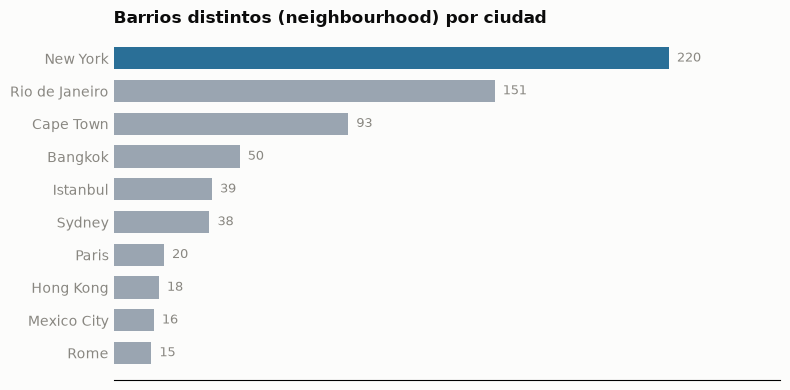

In [8]:
cobertura = listings.groupby('city').agg(
    anuncios=('listing_id', 'size'),
    anfitriones=('host_id', 'nunique'),
    con_district=('district', 'count'),
    barrios=('neighbourhood', 'nunique'),
    coords_nulas=('latitude', lambda s: s.isna().sum()),
)
cobertura['pct_district'] = (cobertura['con_district'] / cobertura['anuncios'] * 100).round(1)
cobertura['anuncios_por_barrio'] = (cobertura['anuncios'] / cobertura['barrios']).round(0)
display(cobertura.drop(columns='con_district').sort_values('anuncios', ascending=False))

ranking(cobertura['anuncios'], 'Anuncios por ciudad')
ranking(cobertura['barrios'], 'Barrios distintos (neighbourhood) por ciudad', destacar='New York')

#### Conclusiones:

- **Las coordenadas están completas en las diez ciudades**, así que ninguna queda descartada de entrada.
- **`district` solo existe en Nueva York**, y ahí está en el 100 % de los anuncios. En las otras nueve la
  columna está vacía entera, sin una sola fila. No es que esté incompleta: no está. Nueva York es la única que
  ofrece un nivel geográfico intermedio entre el barrio y la ciudad.
- **El detalle del barrio también es muy desigual.** Nueva York distingue 220 barrios; después vienen Río de
  Janeiro (151) y Ciudad del Cabo (93). En el extremo contrario, Roma reparte 27.647 anuncios entre 15 barrios
  y París 64.690 entre 20. Dicho en anuncios por barrio: 168 en Nueva York frente a 3.234 en París. París
  tiene más anuncios, pero no se pueden situar con el mismo detalle.
- **El tamaño no es un problema en Nueva York:** 37.012 anuncios de 26.765 anfitriones, segunda del fichero
  por detrás de París.

Nueva York destaca en lo que más importa para este problema. Pero esto por sí solo no justifica descartar las
demás: habría que ver si se pueden juntar.

## 2. ¿SON COMPARABLES LOS PRECIOS ENTRE CIUDADES?

Para entrenar un modelo con las diez ciudades, `price` tiene que significar lo mismo en todas las filas. Y en
la lista de columnas de la primera celda no aparece ninguna divisa, lo cual deja dos posibilidades: o todos
los precios están convertidos a una moneda común, o cada uno viene en la moneda local y el fichero no lo dice.

No hay metadato que lo aclare, así que hay que deducirlo de los propios números. Si todas las ciudades
compartieran moneda, sus precios serían del mismo orden de magnitud.

,p05,p50,p95,maximo
city,,,,
Rome,25.0,65.0,240.00,10571
Paris,35.0,80.0,270.00,12000
New York,35.0,99.0,349.00,10000
Sydney,40.0,120.0,700.00,28613
Istanbul,79.0,252.0,1185.00,179532
Rio de Janeiro,78.0,280.0,1957.00,625216
Hong Kong,144.0,386.0,1938.00,83665
Mexico City,225.0,664.0,2861.15,499000
Cape Town,350.0,1069.0,7867.50,180000


Mediana mas alta / mediana mas baja: x17


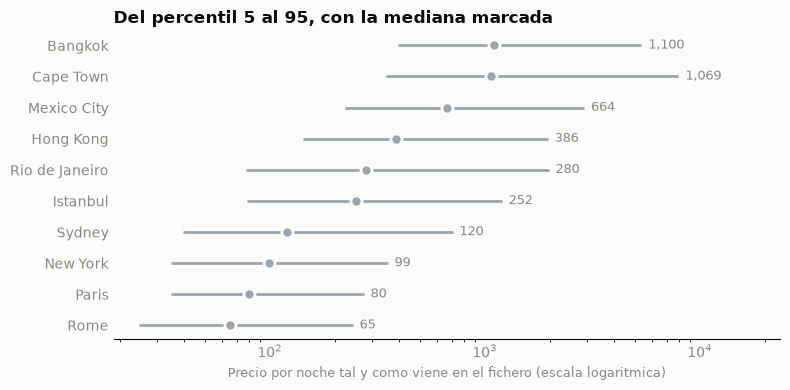

In [ ]:
escala = validos.groupby('city')['price'].agg(
    p05=lambda s: s.quantile(0.05), p50='median', p95=lambda s: s.quantile(0.95), maximo='max')
escala = escala.sort_values('p50')
display(escala)

fig, ax = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for ciudad, fila in escala.iterrows():
    ax.plot([fila['p05'], fila['p95']], [ciudad, ciudad], color=COLOR_CONTEXTO, lw=2, solid_capstyle='round')
    ax.plot(fila['p50'], ciudad, 'o', color=COLOR_CONTEXTO, markersize=8, markeredgecolor=SURFACE,
             markeredgewidth=2)
    ax.text(fila['p95'], ciudad, f"  {fila['p50']:,.0f}", va='center', fontsize=9, color=INK_MUTED)
ax.set_xscale('log')
ax.set_xlim(right=escala['p95'].max() * 3)
ax.set_xlabel('Precio por noche tal y como viene en el fichero (escala logaritmica)', color=INK_MUTED,
               fontsize=9)
ax.set_title('Del percentil 5 al 95, con la mediana marcada', loc='left', fontsize=12, color=INK,
              fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(colors=INK_MUTED, length=0)
plt.tight_layout()
plt.show()

Un anuncio típico cuesta 65 en Roma y 1.100 en Bangkok: **17 veces más**. Bangkok no es diecisiete veces más
cara que Roma, así que lo que cambia no es el mercado, es la unidad.

Se puede poner a prueba: si cada ciudad trae su moneda local, basta aplicar el cambio de cada divisa para que
las medianas se junten. Si siguen dispersas, la hipótesis era falsa. La correspondencia ciudad - moneda y los
tipos de cambio de abajo son un supuesto que se declara, no algo que el fichero diga; valen para diagnosticar,
no para construir nada.

In [ ]:
DIVISA_LOCAL = {'New York': 'USD', 'Paris': 'EUR', 'Rome': 'EUR', 'Sydney': 'AUD', 'Hong Kong': 'HKD',
                'Rio de Janeiro': 'BRL', 'Istanbul': 'TRY', 'Mexico City': 'MXN', 'Bangkok': 'THB',
                'Cape Town': 'ZAR'}

comprobacion = escala[['p50']].assign(divisa_supuesta=pd.Series(DIVISA_LOCAL))
# A ~1,2 USD/EUR y ~0,03 USD/THB del momento del volcado, las medianas se juntan en una franja estrecha
APROX_USD = {'USD': 1.0, 'EUR': 1.2, 'AUD': 0.77, 'HKD': 0.129, 'BRL': 0.185,
             'TRY': 0.14, 'MXN': 0.049, 'THB': 0.033, 'ZAR': 0.068}
comprobacion['p50_aprox_usd'] = (comprobacion['p50'] * comprobacion['divisa_supuesta'].map(APROX_USD)).round(0)
display(comprobacion)
print(f"{len(comprobacion)} ciudades, {comprobacion['divisa_supuesta'].nunique()} divisas distintas "
      f"(Paris y Roma comparten el euro)")
print(f"Dispersion de la mediana: x{escala['p50'].max() / escala['p50'].min():.0f} en bruto, "
      f"x{comprobacion['p50_aprox_usd'].max() / comprobacion['p50_aprox_usd'].min():.1f} al pasar a dolares")

,p50,divisa_supuesta,p50_aprox_usd
city,,,
Rome,65.0,EUR,78.0
Paris,80.0,EUR,96.0
New York,99.0,USD,99.0
Sydney,120.0,AUD,92.0
Istanbul,252.0,TRY,35.0
Rio de Janeiro,280.0,BRL,52.0
Hong Kong,386.0,HKD,50.0
Mexico City,664.0,MXN,33.0
Cape Town,1069.0,ZAR,73.0


10 ciudades, 9 divisas distintas (Paris y Roma comparten el euro)
Dispersion de la mediana: x17 en bruto, x3.0 al pasar a dolares


#### Conclusiones:

- **`price` viene en la moneda local de cada ciudad y el fichero no lo documenta.** La prueba está en la
  última columna: al aplicar el cambio aproximado de cada divisa, las diez medianas se juntan en una franja
  de 33 a 99 dólares. La dispersión cae de **×17 a ×3**, y lo que queda ya no es un artefacto de unidades
  sino la diferencia real de precio entre Ciudad de México y Nueva York. Ninguna otra explicación produce ese
  patrón.
- Son **diez ciudades y nueve divisas**: París y Roma comparten el euro.
- **Convertirlas no es una salida.** Haría falta el tipo de cambio de la fecha exacta del volcado, que el
  fichero tampoco da, los tipos de arriba son aproximados y solo sirven para diagnosticar, no para construir
  un target. Y aun con la conversión perfecta quedaría el poder adquisitivo: 100 dólares no compran lo mismo
  en Bangkok que en Nueva York, así que el modelo tendría que aprender también eso.

Con esto ya habría motivo para quedarse con una ciudad. Pero conviene comprobar si el problema es solo la
unidad o va más al fondo.

## 3. ¿SE COMPORTA EL PRECIO IGUAL EN TODAS LAS CIUDADES?

Supongamos resuelto lo de la divisa. Quedaría la pregunta de verdad: ¿un modelo entrenado con las diez
aprendería **una** relación entre las características de un anuncio y su precio, o diez relaciones distintas
mal promediadas?

Se mide con dos cantidades elegidas a propósito porque **la moneda no las afecta**:

- **Elasticidad de la capacidad.** La pendiente de `log(precio)` frente a `log(capacidad)`: cuánto sube el
  precio al doblar las plazas. Cambiar de moneda multiplica todos los precios por una constante, lo que
  desplaza la recta pero no la inclina.
- **Cociente entre tipos de habitación.** La mediana de la habitación privada dividida por la del alojamiento
  entero, dentro de la misma ciudad. Al ser una división de dos precios de la misma moneda, la unidad se
  cancela.

Si estas dos cantidades fueran parecidas en todas las ciudades, el precio funcionaría igual en todas partes y
la divisa sería el único estorbo.

,elasticidad_capacidad,privada_entre_entera,compartida_entre_entera,pct_entera
city,,,,
Bangkok,0.546,0.839,0.378,54.871
Rome,0.621,0.636,0.260,62.400
Hong Kong,0.625,0.435,0.270,36.532
Mexico City,0.704,0.421,0.316,52.587
New York,0.708,0.429,0.321,52.447
Istanbul,0.712,0.466,0.286,50.695
Paris,0.725,0.646,0.415,85.687
Rio de Janeiro,0.879,0.457,0.286,72.478
Sydney,0.998,0.386,0.222,60.535


elasticidad_capacidad      de 0.55 (Bangkok) a 1.12 (Cape Town)  -> x2.1
privada_entre_entera       de 0.39 (Sydney) a 0.84 (Bangkok)  -> x2.2
pct_entera                 de 36.53 (Hong Kong) a 85.69 (Paris)  -> x2.3


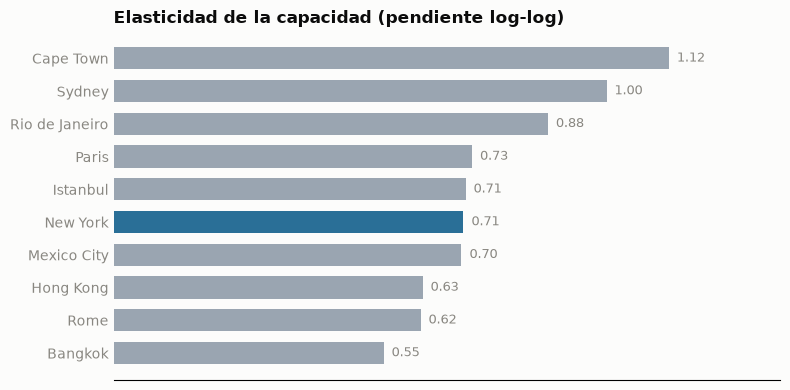

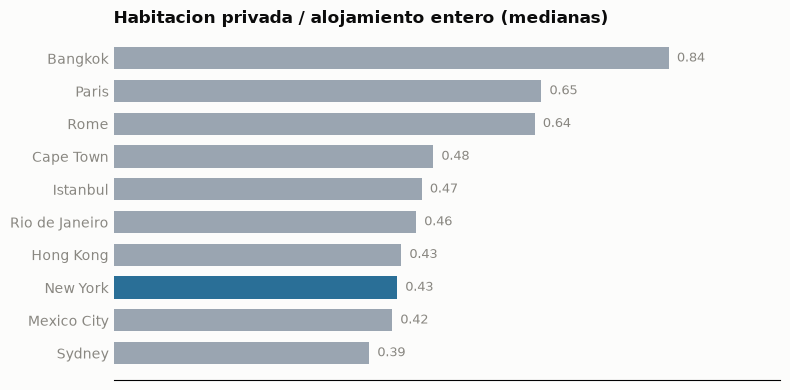

In [ ]:
filas = []
for ciudad, grupo in validos.groupby('city'):
    mediana_tipo = grupo.groupby('room_type')['price'].median()
    entera = mediana_tipo.get('Entire place', np.nan)
    filas.append({
        'city': ciudad,
        'elasticidad_capacidad': np.polyfit(np.log(grupo['accommodates']), np.log(grupo['price']), 1)[0],
        'privada_entre_entera': mediana_tipo.get('Private room', np.nan) / entera,
        'compartida_entre_entera': mediana_tipo.get('Shared room', np.nan) / entera,
        'pct_entera': (grupo['room_type'] == 'Entire place').mean() * 100,
    })
relaciones = pd.DataFrame(filas).set_index('city').sort_values('elasticidad_capacidad')
display(relaciones.round(3))
for columna in ['elasticidad_capacidad', 'privada_entre_entera', 'pct_entera']:
    valores = relaciones[columna]
    print(f'{columna:26s} de {valores.min():.2f} ({valores.idxmin()}) a {valores.max():.2f} '
          f'({valores.idxmax()})')

ranking(relaciones['elasticidad_capacidad'], 'Elasticidad de la capacidad (pendiente log-log)', '{:.2f}',
        destacar='New York')
ranking(relaciones['privada_entre_entera'], 'Habitacion privada / alojamiento entero (medianas)', '{:.2f}',
        destacar='New York')

#### Conclusiones:

- **La capacidad no vale lo mismo en todas partes.** Doblar las plazas multiplica el precio por 1,5 en Bangkok
  (elasticidad 0,55) y lo dobla en Ciudad del Cabo (1,12). Son dos modelos de negocio distintos, y la divisa
  no explica ni una parte de esa diferencia.
- **El tipo de habitación tampoco.** Una habitación privada cuesta el 84 % de un alojamiento entero en Bangkok
  y el 39 % en Sídney. Donde la diferencia es pequeña, la variable apenas informa; donde es grande, es de las
  más potentes. Un modelo único tendría que elegir.
- **Y las ciudades ni siquiera venden lo mismo:** el alojamiento entero es el 86 % del inventario en París y
  el 37 % en Hong Kong.
- **Precaución:** son diferencias descriptivas, no un contraste. No se ha hecho ninguna prueba de hipótesis
  sobre ellas y parte de la diferencia podría venir de la distinta composición del inventario, que es justo lo
  que muestra `pct_entera`. Para la decisión basta con que el orden de magnitud cambie; no hace falta afirmar
  que la diferencia sea estadísticamente significativa.

La respuesta a la pregunta de la sección es que no. Un modelo con las diez ciudades necesitaría interacciones
de la ciudad con casi todo, que es otra forma de decir que son modelos distintos metidos en el mismo saco.

## 4. DECISIÓN

**Vamos a centrarnos en estudiar el mercado de alojamientos en AirBNB solo en la ciudad de New York.**
Por qué hemos tomado esta decision:

1. **No hay un target común.** `price` viene en la moneda local de cada ciudad, el fichero no trae divisa y
   convertirlas exigiría un tipo de cambio que tampoco está. Diez ciudades, nueve monedas.
2. **El precio no se comporta igual.** La elasticidad de la capacidad va de 0,55 a 1,12 y el cociente entre
   tipos de habitación de 0,39 a 0,84, en medidas que la moneda no afecta.

Por qué Nueva York entre las diez:

3. **Es la única con `district`**, completo en sus 37.012 anuncios, mientras que en las otras nueve la columna
   está vacía del todo. Eso da un nivel geográfico intermedio que ninguna otra ciudad ofrece.
4. **Es la que permite situar un anuncio con más detalle:** 220 barrios, el máximo del fichero, y 168 anuncios
   por barrio frente a los 3.234 de París.
5. **Tiene muestra de sobra:** segunda por número de anuncios, solo por detrás de París, y con precios en una
   única divisa.